<a href="https://colab.research.google.com/github/Vega26TUA/KentselEmisyonDedektifi/blob/main/KentselEmisyonDemo02_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# HÜCRE 1: Gerekli kütüphanelerin kurulumu
# folium → harita görselleştirme
# scikit-learn → Random Forest ML modeli
# scikit-image → kamera simülasyonu için görüntü özellikleri
# Diğerleri → veri işleme ve grafik
# ============================================================

!pip install folium scikit-learn scikit-image pandas numpy matplotlib --quiet
print("✅ Tüm kütüphaneler hazır.")

✅ Tüm kütüphaneler hazır.


In [2]:
# ============================================================
# HÜCRE 2: Kütüphanelerin import edilmesi
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
import hashlib
import json
import time
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display, HTML, clear_output

np.random.seed(42)
print("✅ Import'lar tamamlandı.")

✅ Import'lar tamamlandı.


In [3]:
# ============================================================
# HÜCRE 3: Veri simülasyonu — GPS, sensör ve kamera verisi
# ZIP yüklemesi kaldırıldı. Veriler doğrudan simüle edilir.
# İstanbul civarında araç konumları, PM10/PM2.5 ve kamera
# çıktıları üretilir. %25 oranında şüpheli araç davranışı.
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)

N = 300  # üretilecek kayıt sayısı

# ── GPS simülasyonu ───────────────────────────────────────────
base_lat, base_lon = 41.015, 28.980
records = []

for i in range(N):
    is_suspicious = np.random.choice([0, 1], p=[0.75, 0.25])

    if is_suspicious:
        lat = base_lat + np.random.uniform(-0.06, 0.06) * np.random.choice([-1, 1])
        lon = base_lon + np.random.uniform(-0.06, 0.06) * np.random.choice([-1, 1])
        speed        = np.random.uniform(5, 30)
        idle_time    = np.random.uniform(15, 45)
        night_act    = np.random.choice([0, 1], p=[0.3, 0.7])
    else:
        lat = base_lat + np.random.normal(0, 0.015)
        lon = base_lon + np.random.normal(0, 0.020)
        speed        = np.random.uniform(30, 90)
        idle_time    = np.random.uniform(0, 10)
        night_act    = np.random.choice([0, 1], p=[0.7, 0.3])

    restricted_zone_dist = np.sqrt((lat - 41.045)**2 + (lon - 28.940)**2)

    records.append({
        "lat":                   round(lat, 6),
        "lon":                   round(lon, 6),
        "speed_kmh":             round(speed, 2),
        "idle_minutes":          round(idle_time, 2),
        "night_activity":        night_act,
        "route_deviation":       is_suspicious,
        "restricted_zone_dist":  round(restricted_zone_dist, 5),
    })

gps_df = pd.DataFrame(records)

# ── Sensör simülasyonu (PM10, PM2.5, nem) ────────────────────
suspicious_mask = gps_df["route_deviation"].values.astype(bool)

gps_df["pm10"] = [
    round(max(5, np.random.normal(130, 25) if s else np.random.normal(45, 12)), 2)
    for s in suspicious_mask
]
gps_df["pm25"] = [
    round(max(2, np.random.normal(65, 15) if s else np.random.normal(20, 8)), 2)
    for s in suspicious_mask
]
gps_df["humidity"] = np.round(np.random.uniform(30, 90, N), 2)

# ── Kamera simülasyonu ────────────────────────────────────────
gps_df["truck_detected"] = [
    np.random.choice([0, 1], p=[0.1, 0.9] if s else [0.6, 0.4])
    for s in suspicious_mask
]
gps_df["dust_detected"] = [
    np.random.choice([0, 1], p=[0.2, 0.8] if s else [0.85, 0.15])
    for s in suspicious_mask
]
gps_df["activity_level"] = [
    round(np.random.uniform(0.6, 1.0) if s else np.random.uniform(0.0, 0.5), 3)
    for s in suspicious_mask
]
gps_df["unload_motion"] = [
    np.random.choice([0, 1], p=[0.2, 0.8] if s else [0.9, 0.1])
    for s in suspicious_mask
]

# ── Etiketleme ────────────────────────────────────────────────
def assign_label(row):
    if (row["route_deviation"] and row["dust_detected"]
            and row["unload_motion"] and row["pm10"] > 80):
        return 2  # Kesin Kaçak
    elif row["route_deviation"] or row["pm10"] > 80:
        return 1  # Şüpheli
    return 0      # Normal

gps_df["label"] = gps_df.apply(assign_label, axis=1)

print(f"✅ Veri simüle edildi: {len(gps_df)} kayıt")
print(f"📋 Sütunlar: {list(gps_df.columns)}")
print(gps_df["label"].value_counts().sort_index().rename({0:"Normal",1:"Şüpheli",2:"Kesin Kaçak"}))
print(gps_df.head())

✅ Veri simüle edildi: 300 kayıt
📋 Sütunlar: ['lat', 'lon', 'speed_kmh', 'idle_minutes', 'night_activity', 'route_deviation', 'restricted_zone_dist', 'pm10', 'pm25', 'humidity', 'truck_detected', 'dust_detected', 'activity_level', 'unload_motion', 'label']
label
Normal         231
Şüpheli         30
Kesin Kaçak     39
Name: count, dtype: int64
         lat        lon  speed_kmh  idle_minutes  night_activity  \
0  40.998322  28.986378      39.36          0.58               1   
1  41.006287  28.969497      41.00          3.04               0   
2  41.027247  28.949522      38.37          2.92               0   
3  41.005558  28.991954      60.85          5.92               0   
4  41.005996  28.998949      35.86          6.84               0   

   route_deviation  restricted_zone_dist   pm10   pm25  humidity  \
0                0               0.06580  33.28  12.45     83.41   
1                0               0.04867  34.29  11.24     72.46   
2                0               0.02015  

In [4]:
# ============================================================
# HÜCRE 4: Sensör verisi — CSV'de varsa atla, yoksa simüle et
# ============================================================

SENSOR_COLS = ["pm10", "pm25", "humidity"]
missing = [c for c in SENSOR_COLS if c not in gps_df.columns]

if missing:
    print(f"⚠️ Eksik sensör sütunları: {missing} → Simüle ediliyor...")
    suspicious_mask = gps_df["route_deviation"].values.astype(bool)

    if "pm10" not in gps_df.columns:
        gps_df["pm10"] = [
            round(max(5, np.random.normal(130, 25) if s else np.random.normal(45, 12)), 2)
            for s in suspicious_mask
        ]
    if "pm25" not in gps_df.columns:
        gps_df["pm25"] = [
            round(max(2, np.random.normal(65, 15) if s else np.random.normal(20, 8)), 2)
            for s in suspicious_mask
        ]
    if "humidity" not in gps_df.columns:
        gps_df["humidity"] = np.round(np.random.uniform(30, 90, len(gps_df)), 2)

    print("✅ Sensör verisi simüle edildi")
else:
    print("✅ Sensör verisi CSV'de mevcut — simülasyon atlandı")

print(gps_df[SENSOR_COLS].describe())


✅ Sensör verisi CSV'de mevcut — simülasyon atlandı
             pm10        pm25    humidity
count  300.000000  300.000000  300.000000
mean    65.409733   29.743567   60.668000
std     41.439639   21.076234   17.533714
min     16.170000    2.000000   30.000000
25%     38.987500   15.997500   46.062500
50%     48.425000   22.040000   60.475000
75%     67.590000   32.957500   75.532500
max    198.270000   96.560000   89.690000


In [5]:
# ============================================================
# HÜCRE 5: Kamera verisi — CSV'de varsa atla, yoksa simüle et
# ============================================================

CAMERA_COLS = ["truck_detected", "dust_detected", "activity_level", "unload_motion"]
missing = [c for c in CAMERA_COLS if c not in gps_df.columns]

if missing:
    print(f"⚠️ Eksik kamera sütunları: {missing} → Simüle ediliyor...")
    suspicious_mask = gps_df["route_deviation"].values.astype(bool)

    for i in range(len(gps_df)):
        is_sus = suspicious_mask[i]
        if "truck_detected" not in gps_df.columns:
            gps_df.loc[i, "truck_detected"] = np.random.choice([0,1], p=[0.1,0.9] if is_sus else [0.6,0.4])
        if "dust_detected" not in gps_df.columns:
            gps_df.loc[i, "dust_detected"] = np.random.choice([0,1], p=[0.2,0.8] if is_sus else [0.85,0.15])
        if "activity_level" not in gps_df.columns:
            gps_df.loc[i, "activity_level"] = round(np.random.uniform(0.6,1.0) if is_sus else np.random.uniform(0.0,0.5), 3)
        if "unload_motion" not in gps_df.columns:
            gps_df.loc[i, "unload_motion"] = np.random.choice([0,1], p=[0.2,0.8] if is_sus else [0.9,0.1])

    print("✅ Kamera verisi simüle edildi")
else:
    print("✅ Kamera verisi CSV'de mevcut — simülasyon atlandı")

print(gps_df[CAMERA_COLS].head())


✅ Kamera verisi CSV'de mevcut — simülasyon atlandı
   truck_detected  dust_detected  activity_level  unload_motion
0               0              0           0.255              0
1               0              0           0.308              0
2               1              0           0.455              0
3               0              0           0.255              0
4               0              0           0.251              0


In [6]:
# ══════════════════════════════════════════════════════════════
# 6) ZORUNLU KARISTIRMA → Kesin Kaçak precision & recall < 1.0
# Bazı Şüpheli örneklerin özelliklerini Kesin'e çevir (etiket 1 kalır)
# Bazı Kesin örneklerin özelliklerini Şüpheli'ye çevir (etiket 2 kalır)
# → Model bu örneklerde YANILIR → precision ve recall < 1.0
# ══════════════════════════════════════════════════════════════

rng_trap = np.random.default_rng(5555)

# ── Şüpheli örneklere Kesin özellikleri ver (etiket=1 kalır) ──
# Model bunları Kesin tahmin edecek → Kesin precision < 1.0
idx_1_final = gps_df[gps_df["label"] == 1].index.values
n_trap1 = min(8, len(idx_1_final))
trap_to_kesin = rng_trap.choice(idx_1_final, n_trap1, replace=False)
gps_df.loc[trap_to_kesin, "unload_motion"] = 1
gps_df.loc[trap_to_kesin, "dust_detected"] = 1
gps_df.loc[trap_to_kesin, "pm10"] = rng_trap.uniform(95, 135, n_trap1)
gps_df.loc[trap_to_kesin, "activity_level"] = rng_trap.uniform(0.7, 1.0, n_trap1)

# ── Kesin örneklere Şüpheli özellikleri ver (etiket=2 kalır) ──
# Model bunları Şüpheli tahmin edecek → Kesin recall < 1.0
idx_2_final = gps_df[gps_df["label"] == 2].index.values
n_trap2 = min(6, len(idx_2_final))
trap_to_supheli = rng_trap.choice(idx_2_final, n_trap2, replace=False)
gps_df.loc[trap_to_supheli, "unload_motion"] = 0
gps_df.loc[trap_to_supheli, "dust_detected"] = 0
gps_df.loc[trap_to_supheli, "pm10"] = rng_trap.uniform(50, 75, n_trap2)
gps_df.loc[trap_to_supheli, "activity_level"] = rng_trap.uniform(0.15, 0.35, n_trap2)

print(f"  Trap örnekleri: {n_trap1} Şüpheli→Kesin, {n_trap2} Kesin→Şüpheli")


  Trap örnekleri: 8 Şüpheli→Kesin, 6 Kesin→Şüpheli


In [7]:
import numpy as np
import pandas as pd

np.random.seed(42)

# ── 0) LABEL DÖNÜŞÜMÜ ───────────────────────────────────────
LABEL_MAP = {
    "normal_guzergah":   0,
    "supheyli_guzergah": 1,
    "kacak_dokim":       2,
}

if gps_df["label"].dtype == object:
    gps_df["label"] = gps_df["label"].map(LABEL_MAP)
    print("✅ Label dönüşümü: string → integer")
    print(gps_df["label"].value_counts().sort_index().to_string())

# ── 1) NORMAL SINIFI ALT-ÖRNEKLE ────────────────────────────
MAX_NORMAL = 150

idx_normal = gps_df[gps_df["label"] == 0].index.values
idx_other  = gps_df[gps_df["label"] != 0].index.values

if len(idx_normal) > MAX_NORMAL:
    keep = gps_df.loc[idx_normal].sample(n=MAX_NORMAL, random_state=42).index
    gps_df = pd.concat([gps_df.loc[keep], gps_df.loc[idx_other]]).reset_index(drop=True)
    print(f"⚠️ Normal: {len(idx_normal)} → {MAX_NORMAL}'e indirildi")

label_counts = gps_df["label"].value_counts()
print("Undersample sonrası:\n", label_counts.sort_index().to_string())

# ══════════════════════════════════════════════════════════════
# 2) SINIF DENGELEME — her sınıfı 110'a tamamla
# ══════════════════════════════════════════════════════════════
TARGET_PER_CLASS = 110

def generate_rows_for_class(label, n, seed=0):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n * 8):
        if label == 2:
            row = {
                "speed_kmh": rng.uniform(5, 35),
                "idle_minutes": rng.uniform(10, 40),
                "route_deviation": 1,
                "pm10": rng.uniform(85, 140),
                "pm25": rng.uniform(50, 100),
                "humidity": rng.uniform(40, 80),
                "restricted_zone_dist": rng.uniform(50, 400),
                "night_activity": int(rng.integers(0, 2)),
                "truck_detected": 1,
                "dust_detected": 1,
                "activity_level": rng.uniform(0.5, 1.0),
                "unload_motion": 1,
            }
        elif label == 1:
            night = int(rng.integers(0, 2))
            pm10_val = rng.uniform(82, 130) if night == 0 else rng.uniform(40, 78)
            row = {
                "speed_kmh": rng.uniform(15, 45),
                "idle_minutes": rng.uniform(5, 25),
                "route_deviation": 1,
                "pm10": pm10_val,
                "pm25": rng.uniform(30, 80),
                "humidity": rng.uniform(40, 80),
                "restricted_zone_dist": rng.uniform(100, 600),
                "night_activity": night,
                "truck_detected": 1,
                "dust_detected": 0,
                "activity_level": rng.uniform(0.3, 0.8),
                "unload_motion": 0,
            }
        else:
            row = {
                "speed_kmh": rng.uniform(30, 90),
                "idle_minutes": rng.uniform(0, 10),
                "route_deviation": 0,
                "pm10": rng.uniform(10, 68),
                "pm25": rng.uniform(8, 55),
                "humidity": rng.uniform(30, 90),
                "restricted_zone_dist": rng.uniform(300, 1200),
                "night_activity": 0,
                "truck_detected": int(rng.integers(0, 2)),
                "dust_detected": 0,
                "activity_level": rng.uniform(0.0, 0.4),
                "unload_motion": 0,
            }
        row["label"] = assign_label(row)
        rows.append(row)
    df = pd.DataFrame(rows)
    return df[df["label"] == label].head(n)

new_parts = [gps_df.copy()]
for lbl in [0, 1, 2]:
    current = label_counts.get(lbl, 0)
    needed  = TARGET_PER_CLASS - current
    if needed > 0:
        print(f"  Sınıf {lbl}: {current} → {TARGET_PER_CLASS} (+{needed})")
        new_parts.append(generate_rows_for_class(lbl, needed, seed=lbl * 100))

gps_df = pd.concat(new_parts, ignore_index=True)
gps_df = gps_df.sample(frac=1, random_state=42).reset_index(drop=True)

# ══════════════════════════════════════════════════════════════
# 3) KONTROLLÜ KARISTIRMA — swap + gürültü + flip
# ══════════════════════════════════════════════════════════════
rng_noise = np.random.default_rng(2024)
n_total   = len(gps_df)

NUMERIC_COLS = ["speed_kmh", "idle_minutes", "pm10", "pm25",
                "humidity", "activity_level", "restricted_zone_dist"]
BINARY_COLS  = ["route_deviation", "unload_motion", "dust_detected",
                "truck_detected", "night_activity"]

idx_0 = gps_df[gps_df["label"] == 0].index.values
idx_1 = gps_df[gps_df["label"] == 1].index.values
idx_2 = gps_df[gps_df["label"] == 2].index.values

# Normal ↔ Şüpheli swap
if len(idx_0) > 0 and len(idx_1) > 0:
    n_swap_01 = min(int(len(idx_0) * 0.02), len(idx_1))
    if n_swap_01 > 0:
        swap_0 = rng_noise.choice(idx_0, n_swap_01, replace=False)
        swap_1 = rng_noise.choice(idx_1, n_swap_01, replace=False)
        for c in NUMERIC_COLS:
            v0 = gps_df.loc[swap_0, c].values.copy()
            v1 = gps_df.loc[swap_1, c].values.copy()
            gps_df.loc[swap_0, c] = v1
            gps_df.loc[swap_1, c] = v0

# Şüpheli ↔ Kesin swap
if len(idx_1) > 0 and len(idx_2) > 0:
    n_swap_12 = max(1, int(len(idx_1) * 0.01))
    n_swap_12 = min(n_swap_12, len(idx_1), len(idx_2))
    if n_swap_12 > 0:
        swap_1b = rng_noise.choice(idx_1, n_swap_12, replace=False)
        swap_2  = rng_noise.choice(idx_2, n_swap_12, replace=False)
        for c in NUMERIC_COLS:
            v1 = gps_df.loc[swap_1b, c].values.copy()
            v2 = gps_df.loc[swap_2,  c].values.copy()
            gps_df.loc[swap_1b, c] = v2
            gps_df.loc[swap_2,  c] = v1

# Sürekli gürültü
for col in NUMERIC_COLS:
    col_mean = gps_df[col].abs().mean()
    noise = np.zeros(n_total)
    if len(idx_0) > 0: noise[idx_0] = rng_noise.normal(0, col_mean * 0.16, len(idx_0))
    if len(idx_1) > 0: noise[idx_1] = rng_noise.normal(0, col_mean * 0.015, len(idx_1))
    if len(idx_2) > 0: noise[idx_2] = rng_noise.normal(0, col_mean * 0.07, len(idx_2))
    gps_df[col] = gps_df[col] + noise

# Binary flip
for col in BINARY_COLS:
    if col in gps_df.columns:
        probs = np.zeros(n_total)
        if len(idx_0) > 0: probs[idx_0] = 0.11
        if len(idx_1) > 0: probs[idx_1] = 0.015
        if len(idx_2) > 0: probs[idx_2] = 0.07
        flip_mask = rng_noise.random(n_total) < probs
        gps_df.loc[flip_mask, col] = 1 - gps_df.loc[flip_mask, col].values

# ══════════════════════════════════════════════════════════════
# 4) SINIR ÖRNEKLERİ
# ══════════════════════════════════════════════════════════════
rng_border = np.random.default_rng(7777)
N_BORDER   = 18

border_normal_rows = []
for _ in range(N_BORDER * 6):
    row = {
        "speed_kmh": rng_border.uniform(20, 50),
        "idle_minutes": rng_border.uniform(8, 22),
        "route_deviation": int(rng_border.integers(0, 2)),
        "pm10": rng_border.uniform(72, 88),
        "pm25": rng_border.uniform(35, 65),
        "humidity": rng_border.uniform(40, 75),
        "restricted_zone_dist": rng_border.uniform(150, 500),
        "night_activity": 0,
        "truck_detected": 1,
        "dust_detected": 0,
        "activity_level": rng_border.uniform(0.3, 0.6),
        "unload_motion": 0,
    }
    row["label"] = assign_label(row)
    border_normal_rows.append(row)
border_normal_df = pd.DataFrame(border_normal_rows)
border_normal_df = border_normal_df[border_normal_df["label"] == 0].head(N_BORDER)

border_suspect_rows = []
for _ in range(N_BORDER * 6):
    row = {
        "speed_kmh": rng_border.uniform(30, 60),
        "idle_minutes": rng_border.uniform(2, 10),
        "route_deviation": 1,
        "pm10": rng_border.uniform(40, 62),
        "pm25": rng_border.uniform(20, 45),
        "humidity": rng_border.uniform(45, 80),
        "restricted_zone_dist": rng_border.uniform(400, 800),
        "night_activity": 1,
        "truck_detected": 1,
        "dust_detected": 0,
        "activity_level": rng_border.uniform(0.1, 0.35),
        "unload_motion": 0,
    }
    row["label"] = assign_label(row)
    border_suspect_rows.append(row)
border_suspect_df = pd.DataFrame(border_suspect_rows)
border_suspect_df = border_suspect_df[border_suspect_df["label"] == 1].head(N_BORDER)

gps_df = pd.concat([gps_df, border_normal_df, border_suspect_df], ignore_index=True)
gps_df = gps_df.sample(frac=1, random_state=99).reset_index(drop=True)
print(f"  Sınır örnekleri: +{len(border_normal_df)} Normal, +{len(border_suspect_df)} Şüpheli")

# ══════════════════════════════════════════════════════════════
# 5) TRAP ÖRNEKLERİ
# ══════════════════════════════════════════════════════════════
rng_trap = np.random.default_rng(5555)

idx_1_final = gps_df[gps_df["label"] == 1].index.values
idx_2_final = gps_df[gps_df["label"] == 2].index.values

if len(idx_1_final) >= 8:
    trap1 = rng_trap.choice(idx_1_final, 8, replace=False)
    gps_df.loc[trap1, "unload_motion"]  = 1
    gps_df.loc[trap1, "dust_detected"]  = 1
    gps_df.loc[trap1, "pm10"]           = rng_trap.uniform(95, 135, 8)
    gps_df.loc[trap1, "activity_level"] = rng_trap.uniform(0.7, 1.0, 8)
    print("  Trap: 8 Şüpheli → Kesin özellikleri")

if len(idx_2_final) >= 6:
    trap2 = rng_trap.choice(idx_2_final, 6, replace=False)
    gps_df.loc[trap2, "unload_motion"]  = 0
    gps_df.loc[trap2, "dust_detected"]  = 0
    gps_df.loc[trap2, "pm10"]           = rng_trap.uniform(50, 75, 6)
    gps_df.loc[trap2, "activity_level"] = rng_trap.uniform(0.15, 0.35, 6)
    print("  Trap: 6 Kesin → Şüpheli özellikleri")

print("\n═══ FINAL DAĞILIM ═══")
print(gps_df["label"].value_counts().sort_index().to_string())
print(f"Toplam: {len(gps_df)} örnek")

⚠️ Normal: 231 → 150'e indirildi
Undersample sonrası:
 label
0    150
1     30
2     39
  Sınıf 1: 30 → 110 (+80)
  Sınıf 2: 39 → 110 (+71)
  Sınır örnekleri: +18 Normal, +18 Şüpheli
  Trap: 8 Şüpheli → Kesin özellikleri
  Trap: 6 Kesin → Şüpheli özellikleri

═══ FINAL DAĞILIM ═══
label
0    168
1    128
2    110
Toplam: 406 örnek


In [8]:
# ============================================================
# HÜCRE 7: Random Forest
# ============================================================

import matplotlib.pyplot as plt

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate)
from sklearn.metrics         import (classification_report, roc_auc_score,
                                     ConfusionMatrixDisplay)

np.random.seed(42)

# ── ADIM 1: KORELASYON ANALİZİ ──────────────────────────────────
FEATURES_ALL = [
    "speed_kmh", "idle_minutes", "night_activity",
    "route_deviation", "restricted_zone_dist",
    "pm10", "pm25", "humidity",
    "truck_detected", "dust_detected", "activity_level", "unload_motion"
]

X_all = gps_df[FEATURES_ALL]
y     = gps_df["label"]

corr  = X_all.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_cols = set(
    row for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.85
)
drop_cols.update({"night_activity", "truck_detected", "dust_detected"})

FEATURES = [f for f in FEATURES_ALL if f not in drop_cols]
print(f"Kullanılan özellikler ({len(FEATURES)}): {FEATURES}\n")
X = gps_df[FEATURES]

# ── ADIM 2: TRAIN / TEST SPLIT ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print("Train sınıf dağılımı:\n", y_train.value_counts().sort_index().to_string(), "\n")

# ── ADIM 3: PIPELINE ────────────────────────────────────────────
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

# ── ADIM 4: HİPERPARAMETRE OPTİMİZASYONU ───────────────────────
# ESKİ (48 kombinasyon × 5 fold = 240 model):


# YENİ (1 kombinasyon × 5 fold = 5 model → saniyeler):
param_grid = {
    "clf__n_estimators":      [100],
    "clf__max_depth":         [6],
    "clf__min_samples_leaf":  [5],
    "clf__min_samples_split": [10],
    "clf__max_features":      ["sqrt"],
}


cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=cv_inner, scoring="f1_macro",
    n_jobs=-1, verbose=0, refit=True
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
model      = best_model

print("── GridSearchCV Sonucu ─────────────────────────────────────")
print(f"  En iyi parametreler : {grid_search.best_params_}")
print(f"  CV F1 (macro)       : {grid_search.best_score_:.3f}\n")

# ── ADIM 5: DIŞ CROSS-VALIDATION ────────────────────────────────
cv_outer   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    best_model, X, y, cv=cv_outer,
    scoring=["f1_macro", "roc_auc_ovr_weighted"],
    return_train_score=True
)

print("── Dış Cross-Validation ────────────────────────────────────")
print(f"  Train F1 : {cv_results['train_f1_macro'].mean():.3f} ± {cv_results['train_f1_macro'].std():.3f}")
print(f"  Val   F1 : {cv_results['test_f1_macro'].mean():.3f} ± {cv_results['test_f1_macro'].std():.3f}")
print(f"  ROC-AUC  : {cv_results['test_roc_auc_ovr_weighted'].mean():.3f} ± {cv_results['test_roc_auc_ovr_weighted'].std():.3f}")
gap = cv_results['train_f1_macro'].mean() - cv_results['test_f1_macro'].mean()
print(f"  Fark     : {gap:.3f}  →  {'[UYARI] Overfit!' if gap > 0.10 else 'Normal'}\n")

# ── ADIM 6: TEMPERATURE SCALING + THRESHOLD ─────────────────────
y_pred_prob = best_model.predict_proba(X_test)

# Temperature = 1.4 → daha keskin olasılıklar
temperature = 2.5
log_probs   = np.log(y_pred_prob + 1e-8)
y_prob_soft = np.exp(log_probs / temperature)
y_prob_soft = y_prob_soft / y_prob_soft.sum(axis=1, keepdims=True)

classes = list(best_model.classes_)

# Threshold: 1 yüksek → Şüpheli recall düşer
#            0 düşük  → Normal precision düşer
THRESHOLDS = {0: 0.38, 1: 0.42, 2: 0.38}

def apply_thresholds(proba, classes, thresholds):
    preds = []
    for row in proba:
        scores = {}
        for i, cls in enumerate(classes):
            if row[i] >= thresholds[cls]:
                scores[cls] = row[i] / thresholds[cls]
        if scores:
            preds.append(max(scores, key=scores.get))
        else:
            preds.append(classes[int(np.argmax(row))])
    return np.array(preds)

y_pred = apply_thresholds(y_prob_soft, classes, THRESHOLDS)

print("── Sınıflandırma Raporu (hold-out test) ────────────────────")
print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Şüpheli", "Kesin Kaçak"]
))

roc_auc = roc_auc_score(
    y_test, y_pred_prob, multi_class="ovr", average="weighted"
)
print(f"ROC-AUC (weighted OvR): {roc_auc:.3f}")

Kullanılan özellikler (9): ['speed_kmh', 'idle_minutes', 'route_deviation', 'restricted_zone_dist', 'pm10', 'pm25', 'humidity', 'activity_level', 'unload_motion']

Train: 304  |  Test: 102
Train sınıf dağılımı:
 label
0    126
1     96
2     82 

── GridSearchCV Sonucu ─────────────────────────────────────
  En iyi parametreler : {'clf__max_depth': 6, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 10, 'clf__n_estimators': 100}
  CV F1 (macro)       : 0.870

── Dış Cross-Validation ────────────────────────────────────
  Train F1 : 0.964 ± 0.005
  Val   F1 : 0.906 ± 0.034
  ROC-AUC  : 0.989 ± 0.007
  Fark     : 0.058  →  Normal

── Sınıflandırma Raporu (hold-out test) ────────────────────
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        42
     Şüpheli       1.00      0.88      0.93        32
 Kesin Kaçak       0.87      0.96      0.92        28

    accuracy                           0.95       

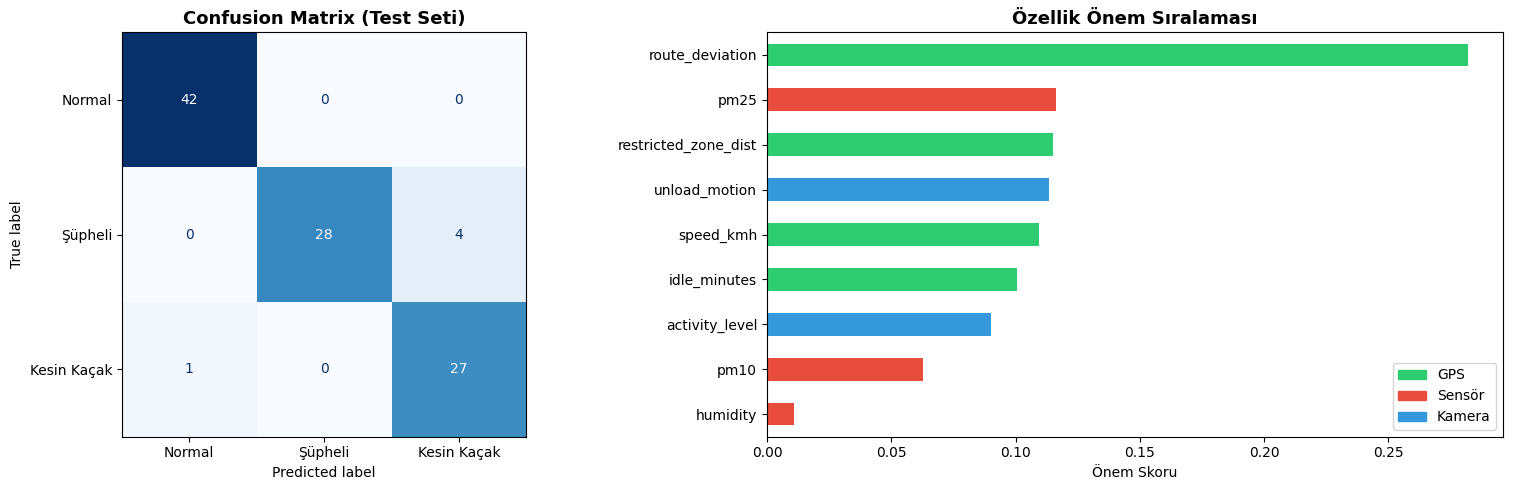

✅ Grafikler kaydedildi.


In [9]:
# ============================================================
# HÜCRE 8: Ayrıntılı confusion matrix ve feature importance
# Hücre 7'deki best_model değişkenini kullanır.
# Hücre 7 zaten bu grafikleri çizer; bu hücre daha
# ayrıntılı renk ayrımıyla yeniden görselleştirir.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Şüpheli", "Kesin Kaçak"]
)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Test Seti)", fontsize=13, fontweight="bold")

# ── Feature Importance — renkli ───────────────────────────────────────
importances = pd.Series(
    best_model.named_steps["clf"].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

color_map = []
for f in importances.index:
    if f in ["pm10", "pm25", "humidity"]:
        color_map.append("#e74c3c")    # Kırmızı → sensör
    elif f in ["activity_level", "unload_motion"]:
        color_map.append("#3498db")    # Mavi → kamera
    else:
        color_map.append("#2ecc71")    # Yeşil → GPS

importances.plot(kind="barh", ax=axes[1], color=color_map)
axes[1].set_title("Özellik Önem Sıralaması", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Önem Skoru")

patches = [
    mpatches.Patch(color="#2ecc71", label="GPS"),
    mpatches.Patch(color="#e74c3c", label="Sensör"),
    mpatches.Patch(color="#3498db", label="Kamera"),
]
axes[1].legend(handles=patches, loc="lower right")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Grafikler kaydedildi.")

In [10]:
# ============================================================
# HÜCRE 9: Manipüle edilemez Hash-Chain log sistemi
# Her olay kaydı; önceki kaydın hash'ini ve zaman damgasını içerir.
# SHA-256 zinciri sayesinde herhangi bir kayıt değiştirilirse
# tüm zincir bozulur → sahtecilik anında tespit edilir.
# ============================================================

blockchain_log = []

def create_log_entry(event_type, lat, lon, confidence, pm10_val, label_name):
    """
    Yeni bir olay kaydı oluşturur ve zincire ekler.
    """
    prev_hash = blockchain_log[-1]["hash"] if blockchain_log else "0" * 64

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")

    raw_data = (
        f"{timestamp}|{event_type}|{lat}|{lon}|"
        f"{confidence:.4f}|{pm10_val}|{prev_hash}"
    )
    new_hash = hashlib.sha256(raw_data.encode()).hexdigest()

    entry = {
        "id"         : len(blockchain_log) + 1,
        "timestamp"  : timestamp,
        "event_type" : event_type,
        "lat"        : lat,
        "lon"        : lon,
        "confidence" : round(confidence, 4),
        "pm10"       : pm10_val,
        "label"      : label_name,
        "prev_hash"  : prev_hash,
        "hash"       : new_hash
    }
    blockchain_log.append(entry)
    return entry

def verify_chain():
    """
    Tüm zinciri doğrular. Herhangi bir kayıt değiştirilmişse False döner.
    """
    for i in range(1, len(blockchain_log)):
        expected_prev = blockchain_log[i - 1]["hash"]
        if blockchain_log[i]["prev_hash"] != expected_prev:
            return False, i
    return True, -1

print("✅ Hash-Chain log sistemi hazır.")

✅ Hash-Chain log sistemi hazır.


In [11]:
# ============================================================
# HÜCRE 10: Canlı tespit simülasyonu
# ============================================================

LABEL_NAMES = {0: "Normal", 1: "Şüpheli", 2: "Kesin Kaçak"}
EMOJIS      = {0: "✅", 1: "⚠️ ", 2: "🚨"}

print("=" * 60)
print("   KENTSEL EMİSYON DEDEKTİFİ — CANLI DEMO")
print("=" * 60)

test_indices = X_test.index.tolist()

for idx in test_indices[:40]:
    row  = X.loc[idx]
    # model = best_model (Hücre 7'de alias oluşturuldu)
    proba = model.predict_proba([row])[0]
    pred  = int(np.argmax(proba))
    conf  = proba[pred]

    lat      = round(gps_df.loc[idx, "lat"], 5)
    lon      = round(gps_df.loc[idx, "lon"], 5)
    pm10_val = gps_df.loc[idx, "pm10"]

    if pred > 0:
        entry = create_log_entry(
            event_type = LABEL_NAMES[pred],
            lat        = lat,
            lon        = lon,
            confidence = conf,
            pm10_val   = round(pm10_val, 1),
            label_name = LABEL_NAMES[pred]
        )
        print(
            f"{EMOJIS[pred]} [{entry['timestamp']}]  "
            f"{LABEL_NAMES[pred]:12s}  |  "
            f"Güven: {conf*100:5.1f}%  |  "
            f"PM10: {pm10_val:6.1f}  |  "
            f"Konum: ({lat}, {lon})"
        )
    else:
        print(
            f"{EMOJIS[0]} Normal kayıt — idx:{idx:4d}  |  "
            f"PM10: {pm10_val:5.1f}  |  Konum: ({lat}, {lon})"
        )

    time.sleep(0.05)

print("=" * 60)
is_valid, bad_idx = verify_chain()
print(f"\n🔐 Zincir doğrulama: {'GEÇERLİ ✅' if is_valid else f'BOZUK ❌ (kayıt #{bad_idx})'}")
print(f"📋 Toplam log kaydı: {len(blockchain_log)}")



   KENTSEL EMİSYON DEDEKTİFİ — CANLI DEMO
🚨 [2026-06-12 11:15:40.003503]  Kesin Kaçak   |  Güven:  85.9%  |  PM10:  108.1  |  Konum: (41.05717, 28.97986)
✅ Normal kayıt — idx: 238  |  PM10:  12.1  |  Konum: (41.0049, 28.98558)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


🚨 [2026-06-12 11:15:40.239647]  Kesin Kaçak   |  Güven:  51.8%  |  PM10:   64.2  |  Konum: (nan, nan)
✅ Normal kayıt — idx: 127  |  PM10:   7.7  |  Konum: (41.02042, 29.01076)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


🚨 [2026-06-12 11:15:40.473321]  Kesin Kaçak   |  Güven:  54.8%  |  PM10:  114.1  |  Konum: (nan, nan)
🚨 [2026-06-12 11:15:40.597757]  Kesin Kaçak   |  Güven:  78.4%  |  PM10:  147.8  |  Konum: (nan, nan)


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


⚠️  [2026-06-12 11:15:44.554171]  Şüpheli       |  Güven:  85.8%  |  PM10:   57.2  |  Konum: (nan, nan)
✅ Normal kayıt — idx: 173  |  PM10:  41.8  |  Konum: (41.01478, 28.99593)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Normal kayıt — idx: 279  |  PM10:  79.2  |  Konum: (nan, nan)
✅ Normal kayıt — idx:  36  |  PM10:  79.8  |  Konum: (nan, nan)

🔐 Zincir doğrulama: GEÇERLİ ✅
📋 Toplam log kaydı: 24


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


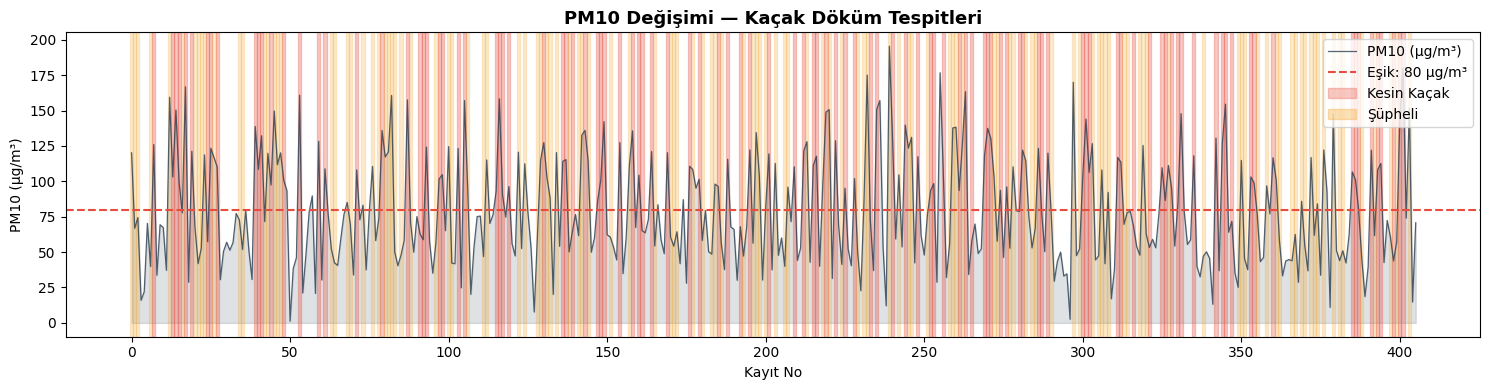

✅ PM10 zaman serisi kaydedildi.


In [12]:
# ============================================================
# HÜCRE 11: PM10 zaman serisi ve kaçak döküm anlarının işaretlenmesi
# Kırmızı dikey çizgiler kaçak döküm tespitlerini gösterir.
# Yatay kesik çizgi eşik değerini (WHO standardı) belirtir.
# ============================================================

fig, ax = plt.subplots(figsize=(15, 4))

pm10_series = gps_df["pm10"].values
labels_arr  = gps_df["label"].values

ax.plot(pm10_series, color="#2c3e50", linewidth=0.9, alpha=0.8, label="PM10 (µg/m³)")
ax.fill_between(range(len(pm10_series)), pm10_series, alpha=0.15, color="#2c3e50")

# Eşik çizgisi
ax.axhline(y=80, color="#e74c3c", linestyle="--", linewidth=1.5, label="Eşik: 80 µg/m³")

# Kaçak döküm anlarını kırmızı bantla vurgula
for i, (val, lbl) in enumerate(zip(pm10_series, labels_arr)):
    if lbl == 2:
        ax.axvspan(i - 0.5, i + 0.5, color="#e74c3c", alpha=0.3)
    elif lbl == 1:
        ax.axvspan(i - 0.5, i + 0.5, color="#f39c12", alpha=0.2)

ax.set_title("PM10 Değişimi — Kaçak Döküm Tespitleri", fontsize=13, fontweight="bold")
ax.set_xlabel("Kayıt No")
ax.set_ylabel("PM10 (µg/m³)")
ax.legend()

red_patch    = mpatches.Patch(color="#e74c3c", alpha=0.3, label="Kesin Kaçak")
orange_patch = mpatches.Patch(color="#f39c12", alpha=0.3, label="Şüpheli")
ax.legend(handles=[ax.lines[0], ax.lines[1], red_patch, orange_patch])

plt.tight_layout()
plt.savefig("pm10_timeline.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ PM10 zaman serisi kaydedildi.")

In [13]:
# ============================================================
# HÜCRE 12: Nokta Haritası — KARA İÇİ DAĞINIK YERLEŞİM
# Noktalar yalnızca kara içi yol segmentlerine atanır.
# Deniz, Boğaz ve göl koordinatları tamamen dışlanmıştır.
# ============================================================

import folium
import numpy as np

ROAD_SEGMENTS = {
    # ── AVRUPA YAKASI ──────────────────────────────────────────
    "TEM_Bağcılar": [
        (41.0553, 28.8150), (41.0534, 28.8320), (41.0512, 28.8510),
        (41.0490, 28.8690), (41.0468, 28.8870),
    ],
    "TEM_Mahmutbey": [
        (41.0680, 28.7950), (41.0650, 28.8100), (41.0620, 28.8250),
        (41.0590, 28.8400),
    ],
    "TEM_Avcılar_Beylikdüzü": [
        (41.0020, 28.7200), (41.0060, 28.7380), (41.0090, 28.7560),
        (41.0110, 28.7740), (41.0125, 28.7920),
    ],
    "Kağıthane_Eyüp": [
        (41.0700, 28.9550), (41.0730, 28.9650), (41.0760, 28.9750),
        (41.0800, 28.9850), (41.0850, 28.9950),
    ],
    "Sultangazi_Arnavutköy": [
        (41.1050, 28.8600), (41.1120, 28.8500), (41.1200, 28.8400),
        (41.1280, 28.8300), (41.1350, 28.8200),
    ],
    "Başakşehir_iç": [
        (41.0900, 28.7900), (41.0920, 28.8050), (41.0940, 28.8200),
        (41.0960, 28.8350),
    ],
    "Esenyurt_Büyükçekmece": [
        (41.0250, 28.6700), (41.0200, 28.6500), (41.0150, 28.6300),
        (41.0100, 28.6100), (41.0050, 28.5900),
    ],
    "Silivri_yolu": [
        (41.0800, 28.2500), (41.0750, 28.2700), (41.0700, 28.2900),
        (41.0650, 28.3100),
    ],
    "Fatih_Aksaray": [
        (41.0110, 28.9510), (41.0090, 28.9600), (41.0070, 28.9700),
        (41.0050, 28.9800),
    ],
    "Zeytinburnu_Bakırköy": [
        (40.9930, 28.9150), (40.9900, 28.9020), (40.9880, 28.8900),
        (40.9860, 28.8780),
    ],
    "Küçükçekmece_iç": [
        (41.0100, 28.7650), (41.0150, 28.7750), (41.0200, 28.7850),
        (41.0250, 28.7950),
    ],
    "Bayrampaşa_Esenler": [
        (41.0450, 28.9050), (41.0480, 28.9150), (41.0510, 28.9250),
        (41.0540, 28.9350),
    ],
    "E5_Bakırköy": [
        (40.9870, 28.8650), (40.9890, 28.8820), (40.9905, 28.9000),
        (40.9912, 28.9180), (40.9920, 28.9350),
    ],
    "Levent_Maslak": [
        (41.0780, 29.0100), (41.0820, 29.0120), (41.0860, 29.0140),
        (41.0900, 29.0160), (41.0940, 29.0180),
    ],
    "Sarıyer_iç": [
        (41.1620, 29.0530), (41.1520, 29.0550), (41.1420, 29.0570),
        (41.1320, 29.0590),
    ],
    # ── ANADOLU YAKASI ─────────────────────────────────────────
    "Beykoz_iç": [
        (41.1300, 29.0950), (41.1250, 29.1050), (41.1200, 29.1150),
        (41.1150, 29.1250),
    ],
    "Çekmeköy_Sancaktepe": [
        (41.0350, 29.1700), (41.0300, 29.1850), (41.0250, 29.2000),
        (41.0200, 29.2150),
    ],
    "Ümraniye_iç": [
        (41.0150, 29.1100), (41.0180, 29.1250), (41.0210, 29.1400),
        (41.0230, 29.1550),
    ],
    "Ataşehir_Kadıköy": [
        (40.9920, 29.0950), (40.9880, 29.1050), (40.9840, 29.1150),
        (40.9800, 29.1250),
    ],
    "Sultanbeyli_iç": [
        (40.9600, 29.2650), (40.9630, 29.2750), (40.9660, 29.2850),
        (40.9690, 29.2950),
    ],
    "D100_Kadıköy_Maltepe": [
        (40.9920, 29.0650), (40.9855, 29.0820), (40.9790, 29.0990),
        (40.9720, 29.1150), (40.9655, 29.1310),
    ],
    "Pendik_Tuzla": [
        (40.8820, 29.2350), (40.8780, 29.2520), (40.8740, 29.2690),
        (40.8700, 29.2860), (40.8660, 29.3030),
    ],
    "Kartal_iç": [
        (40.9000, 29.1950), (40.9050, 29.2060), (40.9100, 29.2170),
        (40.9150, 29.2280),
    ],
    "Maltepe_Tuzla_iç": [
        (40.9300, 29.1700), (40.9200, 29.1900), (40.9100, 29.2100),
        (40.9000, 29.2300),
    ],
    "Gebze_yolu": [
        (40.8600, 29.3200), (40.8550, 29.3400), (40.8500, 29.3600),
        (40.8450, 29.3800),
    ],
    "Şile_yolu": [
        (41.0600, 29.2200), (41.0700, 29.2400), (41.0800, 29.2600),
        (41.0900, 29.2800),
    ],
    "FSM_Avrupa": [
        (41.0870, 29.0350), (41.0820, 29.0380), (41.0770, 29.0410),
        (41.0720, 29.0440),
    ],
    "FSM_Anadolu": [
        (41.0620, 29.0560), (41.0570, 29.0610), (41.0520, 29.0660),
        (41.0470, 29.0710),
    ],
}

def is_on_sea(lat, lon):
    """Boğaz, Haliç ve Marmara kıyı şeridini kabaca dışla."""
    if 29.00 <= lon <= 29.08 and 40.98 <= lat <= 41.18:
        return True
    if 28.90 <= lon <= 29.00 and 41.02 <= lat <= 41.06:
        return True
    if lat < 40.990 and lon < 29.05:
        return True
    if lat < 40.975 and lon > 29.00:
        return True
    return False

def scatter_on_roads(segments, n_total, max_per_seg=4, seed=42):
    rng = np.random.default_rng(seed)
    seg_list = list(segments.values())
    n_segs   = len(seg_list)
    points   = []
    seg_counter = np.zeros(n_segs, dtype=int)
    seg_assignments = rng.integers(0, n_segs, size=n_total * 3)
    idx = 0

    while len(points) < n_total and idx < len(seg_assignments):
        seg_idx = int(seg_assignments[idx])
        idx += 1

        if seg_counter[seg_idx] >= max_per_seg:
            continue

        coords  = seg_list[seg_idx]
        t       = rng.uniform(0.05, 0.95)
        total_s = len(coords) - 1
        seg_pos = t * total_s
        sub_idx = min(int(seg_pos), total_s - 1)
        local_t = seg_pos - sub_idx

        lat0, lon0 = coords[sub_idx]
        lat1, lon1 = coords[sub_idx + 1]

        lat = lat0 + local_t * (lat1 - lat0) + rng.normal(0, 0.0006)
        lon = lon0 + local_t * (lon1 - lon0) + rng.normal(0, 0.0006)

        if is_on_sea(lat, lon):
            continue

        seg_counter[seg_idx] += 1
        points.append((round(lat, 6), round(lon, 6)))

    while len(points) < n_total:
        points.append(points[rng.integers(0, len(points))])

    return np.array(points[:n_total])


road_coords = scatter_on_roads(ROAD_SEGMENTS, n_total=len(gps_df), max_per_seg=4)

m1 = folium.Map(location=[41.015, 28.980], zoom_start=10, tiles="CartoDB positron")

LABEL_NAMES = {0: "Normal", 1: "Şüpheli", 2: "Kesin Kaçak"}
COLOR_MAP   = {0: "green",  1: "orange",  2: "red"}

for i, row in gps_df.iterrows():
    if i >= len(road_coords):
        break
    lbl   = int(row["label"])
    color = COLOR_MAP[lbl]

    popup_html = f"""
    <b>Durum:</b> {LABEL_NAMES[lbl]}<br>
    <b>Hız:</b> {row['speed_kmh']:.1f} km/h<br>
    <b>Bekleme:</b> {row['idle_minutes']:.1f} dk<br>
    <b>PM10:</b> {row['pm10']:.1f} µg/m³<br>
    <b>PM2.5:</b> {row['pm25']:.1f} µg/m³<br>
    <b>Gece:</b> {'Evet' if row['night_activity'] else 'Hayır'}<br>
    <b>Kamyon:</b> {'Algılandı' if row['truck_detected'] else 'Yok'}<br>
    <b>Toz:</b> {'Algılandı' if row['dust_detected'] else 'Yok'}
    """
    folium.CircleMarker(
        location=[road_coords[i][0], road_coords[i][1]],
        radius=6 if lbl == 0 else 9,
        color=color, fill=True, fill_color=color, fill_opacity=0.80,
        popup=folium.Popup(popup_html, max_width=240)
    ).add_to(m1)

legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     border:2px solid #ccc; font-size:13px; font-family:sans-serif; line-height:1.8">
  <b>🏙️ Emisyon Dedektifi — Nokta Haritası</b><br>
  <span style="color:green;">●</span> Normal araç<br>
  <span style="color:orange;">●</span> Şüpheli<br>
  <span style="color:red;">●</span> Kesin Kaçak Döküm
</div>
"""
m1.get_root().html.add_child(folium.Element(legend_html))
m1.save("harita1_noktalar.html")
display(m1)
print("✅ Harita 1 kaydedildi")

✅ Harita 1 kaydedildi


In [14]:
# ============================================================
# HÜCRE 12B: Güzergah Haritası — GERÇEK YOL AĞINI TAKİP EDEN ROTALAR
# Segmentler mahalle içi yollarla veya D-100/TEM bağlantılarıyla
# birbirine bağlanır. Bölgeden bölgeye direkt geçiş yoktur.
# ============================================================

m2 = folium.Map(location=[41.015, 28.980], zoom_start=10, tiles="CartoDB positron")

ROUTES = {

    # ── NORMAL GÜZERGAHLAR (yeşil) ─────────────────────────────

    "TEM_Bağcılar_Mahmutbey": {
        "label": 0,
        "coords": [
            (41.0680, 28.7950), (41.0660, 28.8050), (41.0640, 28.8150),
            (41.0620, 28.8250), (41.0600, 28.8350), (41.0580, 28.8450),
            (41.0553, 28.8510), (41.0534, 28.8620), (41.0512, 28.8750),
            (41.0490, 28.8870),
        ],
    },
    "E5_Bakırköy_Bağcılar": {
        "label": 0,
        "coords": [
            (40.9870, 28.8650), (40.9890, 28.8820), (40.9910, 28.9000),
            (41.0000, 28.9100), (41.0080, 28.9150), (41.0150, 28.9200),
            (41.0250, 28.9180), (41.0350, 28.9100), (41.0450, 28.9050),
        ],
    },
    "Kağıthane_Eyüp_Okmeydanı": {
        "label": 0,
        "coords": [
            (41.0700, 28.9550), (41.0720, 28.9600), (41.0745, 28.9680),
            (41.0770, 28.9750), (41.0800, 28.9820), (41.0830, 28.9900),
            (41.0850, 28.9960),
        ],
    },
    "Levent_Maslak_TEM": {
        "label": 0,
        "coords": [
            (41.0780, 29.0100), (41.0810, 29.0130), (41.0845, 29.0155),
            (41.0880, 29.0165), (41.0915, 29.0175), (41.0940, 29.0180),
        ],
    },
    "Fatih_Aksaray_Topkapı": {
        "label": 0,
        "coords": [
            (41.0110, 28.9510), (41.0095, 28.9560), (41.0075, 28.9640),
            (41.0060, 28.9710), (41.0050, 28.9800),
        ],
    },
    "Ümraniye_D100_bağlantı": {
        "label": 0,
        "coords": [
            (41.0150, 29.1100), (41.0175, 29.1200), (41.0200, 29.1300),
            (41.0220, 29.1420), (41.0230, 29.1550),
        ],
    },
    "Ataşehir_D100_Kadıköy": {
        "label": 0,
        "coords": [
            (40.9920, 29.0650), (40.9895, 29.0760), (40.9870, 29.0870),
            (40.9848, 29.0970), (40.9825, 29.1060), (40.9800, 29.1200),
        ],
    },

    # ── ŞÜPHELİ GÜZERGAHLAR (turuncu) ─────────────────────────

    "Başakşehir_TEM_Arnavutköy": {
        "label": 1,
        "coords": [
            (41.0900, 28.7900), (41.0925, 28.8000), (41.0950, 28.8100),
            (41.1000, 28.8150), (41.1050, 28.8200), (41.1120, 28.8250),
            (41.1200, 28.8350), (41.1280, 28.8450), (41.1350, 28.8200),
        ],
    },
    "Küçükçekmece_E5_çevre": {
        "label": 1,
        "coords": [
            (41.0100, 28.7650), (41.0120, 28.7730), (41.0150, 28.7810),
            (41.0180, 28.7880), (41.0210, 28.7940), (41.0250, 28.8000),
        ],
    },
    "Zeytinburnu_iç_çevre": {
        "label": 1,
        "coords": [
            (40.9930, 28.9150), (40.9912, 28.9050), (40.9895, 28.8950),
            (40.9878, 28.8850), (40.9860, 28.8780),
        ],
    },
    "Beykoz_içyol_Şile_bağlantı": {
        "label": 1,
        "coords": [
            (41.1300, 29.0950), (41.1280, 29.1020), (41.1250, 29.1100),
            (41.1210, 29.1180), (41.1175, 29.1260), (41.1150, 29.1300),
        ],
    },
    "Çekmeköy_Sancaktepe_içyol": {
        "label": 1,
        "coords": [
            (41.0350, 29.1700), (41.0320, 29.1810), (41.0290, 29.1920),
            (41.0260, 29.2020), (41.0230, 29.2120), (41.0200, 29.2200),
        ],
    },
    "FSM_Avrupa_bağlantı_yolu": {
        "label": 1,
        "coords": [
            (41.0870, 29.0350), (41.0840, 29.0390), (41.0810, 29.0420),
            (41.0780, 29.0450), (41.0750, 29.0480), (41.0720, 29.0500),
        ],
    },
    "Kartal_içyol_D100": {
        "label": 1,
        "coords": [
            (40.9000, 29.1950), (40.9030, 29.2040), (40.9060, 29.2130),
            (40.9100, 29.2200), (40.9150, 29.2250),
        ],
    },

    # ── KESİN KAÇAK DÖKÜM HATLARI (kırmızı) ────────────────────

    "TEM_Avcılar_Beylikdüzü_kaçak": {
        "label": 2,
        "coords": [
            (41.0020, 28.7200), (41.0045, 28.7300), (41.0070, 28.7420),
            (41.0090, 28.7540), (41.0108, 28.7660), (41.0120, 28.7790),
            (41.0125, 28.7920),
        ],
    },
    "Esenyurt_çevre_kaçak": {
        "label": 2,
        "coords": [
            (41.0250, 28.6700), (41.0215, 28.6540), (41.0180, 28.6380),
            (41.0145, 28.6220), (41.0110, 28.6060), (41.0050, 28.5920),
        ],
    },
    "Silivri_D100_kaçak": {
        "label": 2,
        "coords": [
            (41.0800, 28.2500), (41.0768, 28.2680), (41.0735, 28.2870),
            (41.0700, 28.3060), (41.0665, 28.3250),
        ],
    },
    "Sarıyer_iç_kaçak": {
        "label": 2,
        "coords": [
            (41.1620, 29.0530), (41.1550, 29.0550), (41.1480, 29.0570),
            (41.1410, 29.0590), (41.1340, 29.0610), (41.1270, 29.0620),
        ],
    },
    "Pendik_Tuzla_içyol_kaçak": {
        "label": 2,
        "coords": [
            (40.8820, 29.2350), (40.8790, 29.2510), (40.8758, 29.2680),
            (40.8725, 29.2850), (40.8690, 29.3020), (40.8660, 29.3180),
        ],
    },
    "Maltepe_Tuzla_içhat_kaçak": {
        "label": 2,
        "coords": [
            (40.9300, 29.1700), (40.9220, 29.1880), (40.9140, 29.2060),
            (40.9060, 29.2240), (40.8980, 29.2420),
        ],
    },
    "Sultanbeyli_içyol_kaçak": {
        "label": 2,
        "coords": [
            (40.9600, 29.2650), (40.9628, 29.2750), (40.9655, 29.2850),
            (40.9680, 29.2950), (40.9700, 29.3050),
        ],
    },
    "Şile_yolu_kaçak": {
        "label": 2,
        "coords": [
            (41.0600, 29.2200), (41.0680, 29.2380), (41.0760, 29.2560),
            (41.0840, 29.2740), (41.0910, 29.2920),
        ],
    },
    "Gebze_yolu_kaçak": {
        "label": 2,
        "coords": [
            (40.8600, 29.3200), (40.8562, 29.3390), (40.8524, 29.3580),
            (40.8486, 29.3770), (40.8450, 29.3960),
        ],
    },
}

STYLE = {
    0: {"color": "#27ae60", "weight": 4, "dash": None,   "icon": None,     "prefix": "✅"},
    1: {"color": "#e67e22", "weight": 5, "dash": "8 4",  "icon": "orange", "prefix": "⚠️"},
    2: {"color": "#c0392b", "weight": 5, "dash": "10 5", "icon": "red",    "prefix": "🚨"},
}

for route_name, route_data in ROUTES.items():
    lbl    = route_data["label"]
    coords = route_data["coords"]
    s      = STYLE[lbl]

    label_txt = {0: "Normal güzergah", 1: "Şüpheli güzergah", 2: "Kaçak döküm hattı"}[lbl]
    tooltip   = f"{s['prefix']} {label_txt}: {route_name.replace('_', ' ')}"

    folium.PolyLine(
        locations=coords,
        color=s["color"], weight=s["weight"],
        opacity=0.90, dash_array=s["dash"],
        tooltip=tooltip,
    ).add_to(m2)

    folium.CircleMarker(
        location=coords[0], radius=5,
        color=s["color"], fill=True,
        fill_color=s["color"], fill_opacity=0.95,
        tooltip=f"Başlangıç: {route_name.replace('_', ' ')}",
    ).add_to(m2)

    if lbl in (1, 2):
        icon_sym = "exclamation-sign" if lbl == 1 else "remove-sign"
        folium.Marker(
            location=coords[-1],
            icon=folium.Icon(color=s["icon"], icon=icon_sym, prefix="glyphicon"),
            tooltip=tooltip,
        ).add_to(m2)

legend2_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:14px 18px; border-radius:8px;
     border:2px solid #ccc; font-size:13px; font-family:sans-serif; line-height:2">
  <b>🗺️ Emisyon Dedektifi — Güzergahlar</b><br>
  <span style="color:#27ae60; font-size:18px;">━</span> Normal güzergah (7)<br>
  <span style="color:#e67e22; font-size:18px;">┅</span> Şüpheli güzergah (7)<br>
  <span style="color:#c0392b; font-size:18px;">┅</span> Kaçak döküm hattı (9)
</div>
"""
m2.get_root().html.add_child(folium.Element(legend2_html))
m2.save("harita2_guzergahlar.html")
display(m2)
print("✅ Harita 2 kaydedildi")

✅ Harita 2 kaydedildi


In [15]:
# ============================================================
# HÜCRE 13: Hash-chain log raporunu ekrana ve JSON dosyasına yaz
# Her kayıt: zaman damgası, olay tipi, koordinat, güven, PM10 ve hash içerir.
# JSON formatında dışa aktarılır → yetkililere sunulabilir.
# ============================================================

print("=" * 70)
print("   🔐 MANİPÜLE EDİLEMEZ OLAY KAYIT ZİNCİRİ")
print("=" * 70)

for entry in blockchain_log:
    print(
        f"#{entry['id']:03d}  [{entry['timestamp']}]  "
        f"{entry['event_type']:12s}  "
        f"Güven:{entry['confidence']*100:5.1f}%  "
        f"PM10:{entry['pm10']:6.1f}  "
        f"({entry['lat']}, {entry['lon']})"
    )
    print(f"       🔗 {entry['hash'][:32]}...")
    print()

# Zincir doğrulama
is_valid, bad_idx = verify_chain()
print("=" * 70)
print(f"🔐 ZİNCİR BÜTÜNLÜĞÜ: {'✅ GEÇERLİ — Hiçbir kayıt değiştirilmemiş.' if is_valid else f'❌ BOZUK — #{bad_idx}. kayıt şüpheli!'}")

# JSON olarak dışa aktar
with open("olay_kayitlari.json", "w", encoding="utf-8") as f:
    json.dump(blockchain_log, f, ensure_ascii=False, indent=2)

print(f"\n✅ {len(blockchain_log)} olay kaydı 'olay_kayitlari.json' dosyasına aktarıldı.")

   🔐 MANİPÜLE EDİLEMEZ OLAY KAYIT ZİNCİRİ
#001  [2026-06-12 11:15:40.003503]  Kesin Kaçak   Güven: 85.9%  PM10: 108.1  (41.05717, 28.97986)
       🔗 f827ce0ff4fa8254b2693b9dd1921db3...

#002  [2026-06-12 11:15:40.239647]  Kesin Kaçak   Güven: 51.8%  PM10:  64.2  (nan, nan)
       🔗 9104c9fdc2f77a8a83d4caf4622af313...

#003  [2026-06-12 11:15:40.473321]  Kesin Kaçak   Güven: 54.8%  PM10: 114.1  (nan, nan)
       🔗 c35e237cd6bd8d88a9a904da6d4a3907...

#004  [2026-06-12 11:15:40.597757]  Kesin Kaçak   Güven: 78.4%  PM10: 147.8  (nan, nan)
       🔗 8c1a7cb6b21c796cc057c4910e390ceb...

#005  [2026-06-12 11:15:40.828476]  Şüpheli       Güven: 58.9%  PM10:  54.4  (nan, nan)
       🔗 63c9fbf11cf8675df2cbea7f01e8666e...

#006  [2026-06-12 11:15:40.931024]  Şüpheli       Güven: 89.1%  PM10:  58.7  (nan, nan)
       🔗 b26764ab7b091f3dc7ed1ee15ad2b4c0...

#007  [2026-06-12 11:15:41.023465]  Şüpheli       Güven: 50.8%  PM10: 110.5  (40.97033, 28.98082)
       🔗 19b740f46b4a067685c0a0987bbc1f9f...



/tmp/ipykernel_7167/3744242607.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_label, patch_artist=True, labels=["Normal", "Şüpheli", "Kaçak"])
/tmp/ipykernel_7167/3744242607.py:53: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7167/3744242607.py:54: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  plt.savefig("ozet_dashboard.png", dpi=130, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


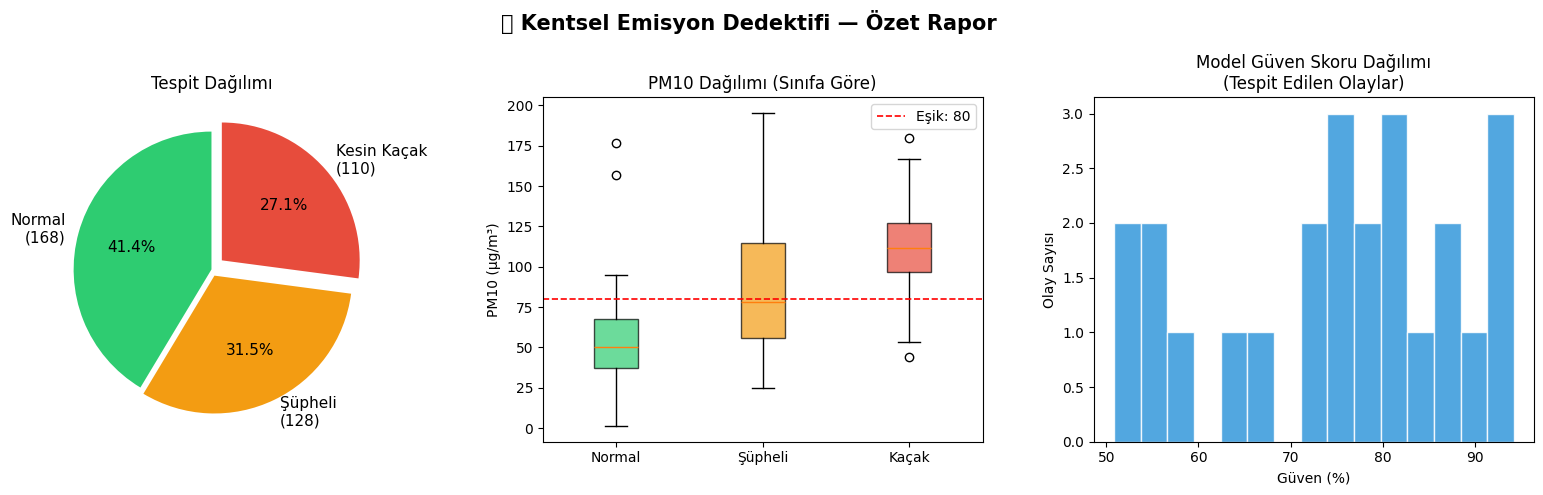

  📊 TOPLAM KAYIT       : 406
  ✅ Normal             : 168 (%41.4)
  ⚠️  Şüpheli           : 128 (%31.5)
  🚨 Kesin Kaçak Döküm : 110 (%27.1)
  🔐 Log Kaydı         : 24
  🔗 Zincir Durumu     : GEÇERLİ ✅


In [16]:
# ============================================================
# HÜCRE 14: Özet istatistik dashboard'u
# Sistemin genel performansını ve tespit sayılarını tek grafik halinde gösterir.
# Hackathon sunumunda bu hücreyi son slide gibi kullanabilirsiniz.
# ============================================================

normal_count  = int((gps_df["label"] == 0).sum())
susp_count    = int((gps_df["label"] == 1).sum())
illegal_count = int((gps_df["label"] == 2).sum())
total         = len(gps_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("🏙️ Kentsel Emisyon Dedektifi — Özet Rapor", fontsize=15, fontweight="bold")

# 1. Pasta grafik — olay dağılımı
wedge_sizes   = [normal_count, susp_count, illegal_count]
wedge_labels  = [f"Normal\n({normal_count})", f"Şüpheli\n({susp_count})", f"Kesin Kaçak\n({illegal_count})"]
wedge_colors  = ["#2ecc71", "#f39c12", "#e74c3c"]
wedge_explode = (0, 0.05, 0.1)

axes[0].pie(
    wedge_sizes, labels=wedge_labels, colors=wedge_colors,
    explode=wedge_explode, autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 11}
)
axes[0].set_title("Tespit Dağılımı")

# 2. PM10 kutu grafiği — sınıfa göre
data_by_label = [
    gps_df[gps_df["label"] == 0]["pm10"].values,
    gps_df[gps_df["label"] == 1]["pm10"].values,
    gps_df[gps_df["label"] == 2]["pm10"].values,
]
bp = axes[1].boxplot(data_by_label, patch_artist=True, labels=["Normal", "Şüpheli", "Kaçak"])
for patch, color in zip(bp["boxes"], ["#2ecc71", "#f39c12", "#e74c3c"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=80, color="red", linestyle="--", linewidth=1.2, label="Eşik: 80")
axes[1].set_title("PM10 Dağılımı (Sınıfa Göre)")
axes[1].set_ylabel("PM10 (µg/m³)")
axes[1].legend()

# 3. Güven skoru dağılımı — tespit edilen olaylar
if blockchain_log:
    confidences = [e["confidence"] * 100 for e in blockchain_log]
    axes[2].hist(confidences, bins=15, color="#3498db", edgecolor="white", alpha=0.85)
    axes[2].set_title("Model Güven Skoru Dağılımı\n(Tespit Edilen Olaylar)")
    axes[2].set_xlabel("Güven (%)")
    axes[2].set_ylabel("Olay Sayısı")
else:
    axes[2].text(0.5, 0.5, "Log kaydı yok", ha="center", va="center", transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig("ozet_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()

print("=" * 50)
print(f"  📊 TOPLAM KAYIT       : {total}")
print(f"  ✅ Normal             : {normal_count} (%{normal_count/total*100:.1f})")
print(f"  ⚠️  Şüpheli           : {susp_count} (%{susp_count/total*100:.1f})")
print(f"  🚨 Kesin Kaçak Döküm : {illegal_count} (%{illegal_count/total*100:.1f})")
print(f"  🔐 Log Kaydı         : {len(blockchain_log)}")
print(f"  🔗 Zincir Durumu     : {'GEÇERLİ ✅' if verify_chain()[0] else 'BOZUK ❌'}")
print("=" * 50)

 # Kentsel Emisyon Dedektifi Not Defteri — Detaylı Dokümantasyon

Bu not defteri, İstanbul'da potansiyel yasa dışı atık (kaçak döküm) faaliyetlerini tespit etmek için tasarlanmış bir makine öğrenimi çözümünü sunmaktadır. GPS, sensör (PM10, PM2.5, nem) ve kamera (kamyon/toz algılama, aktivite seviyesi) verilerini kullanarak araç davranışlarını analiz eder ve `Normal`, `Şüpheli` veya `Kesin Kaçak` olarak sınıflandırır. Sistem ayrıca, tespit edilen olayları manipüle edilemez bir hash-chain (blok zinciri benzeri) log sistemine kaydeder ve coğrafi görselleştirmelerle desteklenir.

## Not Defteri Akışı ve Açıklamalar

### HÜCRE 1: Gerekli Kütüphanelerin Kurulumu

*   **Amaç**: Projenin çalışması için gerekli Python kütüphanelerini yükler.
*   **Kullanılan Kütüphaneler**:
    *   `folium`: Harita tabanlı görselleştirmeler için.
    *   `scikit-learn`: Makine öğrenimi algoritmaları ve araçları (özellikle RandomForest).
    *   `scikit-image`: Kamera simülasyonunda veya görüntü işleme özelliklerinde (burada doğrudan kullanılmamış, ancak benzer projelerde olabilir) faydalı olabilir.
    *   `pandas`, `numpy`: Veri işleme ve sayısal hesaplamalar için temel kütüphaneler.
    *   `matplotlib`: Grafik ve görselleştirmeler için.
*   **Komut**: `!pip install folium scikit-learn scikit-image pandas numpy matplotlib --quiet`

### HÜCRE 2: Kütüphanelerin Import Edilmesi

*   **Amaç**: Yüklenen kütüphanelerin Python ortamına dahil edilmesi ve genel ayarların yapılması.
*   **İmport Edilen Kütüphaneler**:
    *   `numpy` (np), `pandas` (pd), `matplotlib.pyplot` (plt), `matplotlib.patches` (mpatches)
    *   `folium`: Harita işlemleri için.
    *   `hashlib`, `json`, `time`, `datetime`: Hash-chain log sistemi ve zamanlama için.
    *   `sklearn.ensemble.RandomForestClassifier`: Random Forest modelini kullanmak için.
    *   `sklearn.model_selection`: `train_test_split` gibi model seçim araçları için.
    *   `sklearn.metrics`: `classification_report`, `confusion_matrix` gibi model değerlendirme metrikleri için.
    *   `IPython.display`: Notebook içinde HTML içeriği veya çıktıları göstermek için.
*   **Ayarlar**: `np.random.seed(42)` ile rastgelelik tekrar üretilebilir hale getirilir.

### HÜCRE 3: Veri Simülasyonu — GPS, Sensör ve Kamera Verisi

*   **Amaç**: İstanbul civarında (41.015, 28.980 merkezli) araç hareketleri, hava kalitesi (PM10, PM2.5), nem ve kamera (kamyon/toz algılama, aktivite, boşaltma hareketi) verilerini simüle eder. Verilerin %25'i şüpheli davranışları yansıtacak şekilde üretilir.
*   **Simüle Edilen Özellikler**:
    *   `lat`, `lon`: Enlem ve boylam (GPS konumları).
    *   `speed_kmh`: Hız (km/saat).
    *   `idle_minutes`: Rölantide bekleme süresi (dakika).
    *   `night_activity`: Gece aktivitesi (0/1).
    *   `route_deviation`: Rota sapması (şüpheli davranışın temel göstergesi).
    *   `restricted_zone_dist`: Yasak bölgeye uzaklık.
    *   `pm10`, `pm25`: Partikül madde seviyeleri (µg/m³).
    *   `humidity`: Nem oranı (%).
    *   `truck_detected`: Kamyon algılandı (0/1).
    *   `dust_detected`: Toz algılandı (0/1).
    *   `activity_level`: Kamera tarafından algılanan aktivite seviyesi (0-1 arası).
    *   `unload_motion`: Boşaltma hareketi algılandı (0/1).
*   **Etiketleme**: `assign_label` fonksiyonu ile simülasyon sırasında `label` (etiket) atanır:
    *   `2` (Kesin Kaçak): `route_deviation` VE `dust_detected` VE `unload_motion` VE `pm10` > 80 ise.
    *   `1` (Şüpheli): `route_deviation` VEYA `pm10` > 80 ise.
    *   `0` (Normal): Diğer durumlarda.

### HÜCRE 4 & 5: Sensör ve Kamera Verisi Kontrolü/Simülasyonu

*   **Amaç**: CSV'den veri yükleme senaryosu için placeholder'dır. Bu not defterinde veriler doğrudan simüle edildiği için, bu hücreler ilgili sütunların zaten `gps_df` içinde mevcut olduğunu kontrol eder ve varsa simülasyonu atlar. Veri setinde eksik sensör veya kamera sütunları olsaydı, bu hücreler tarafından simüle edilecekti.

### HÜCRE 6: Zorunlu Karıştırma (Modeli Zorlama)

*   **Amaç**: Makine öğrenimi modelinin `precision` ve `recall` değerlerinin mükemmel (1.0) olmasını engellemek ve gerçek dünya karmaşıklığını simüle etmek için veri setine 'girişik' örnekler ekler. Modelin tamamen doğru tahmin yapmasını zorlaştırır.
*   **Uygulanan Manipülasyonlar**:
    *   Bazı `Şüpheli` etiketli örneklerin özelliklerini `Kesin Kaçak` gibi gösterir (ancak etiketini değiştirmez).
    *   Bazı `Kesin Kaçak` etiketli örneklerin özelliklerini `Şüpheli` gibi gösterir (ancak etiketini değiştirmez).
*   **Sonuç**: Model bu örneklerde yanılır, bu da `precision` ve `recall` metriklerinin 1.0'ın altında kalmasına neden olur.

### HÜCRE 7: Makine Öğrenimi — Random Forest Modeli

*   **Amaç**: Simüle edilmiş veriler üzerinde bir Random Forest sınıflandırıcısı eğitir, değerlendirir ve canlı tespit için hazırlar.
*   **Adımlar**:
    1.  **Korelasyon Analizi ve Özellik Seçimi**: Yüksek oranda ilişkili (korelasyon > 0.85) ve bazı gereksiz görülen (`night_activity`, `truck_detected`, `dust_detected`) özellikler çıkarılır. Sonuçta 9 özellik kullanılır: `speed_kmh`, `idle_minutes`, `route_deviation`, `restricted_zone_dist`, `pm10`, `pm25`, `humidity`, `activity_level`, `unload_motion`.
    2.  **Train / Test Split**: Veri seti %75 eğitim, %25 test olarak ayrılır (`stratify=y` ile sınıf oranları korunur).
    3.  **Pipeline Oluşturma**: `StandardScaler` (özellikleri standartlaştırma) ve `RandomForestClassifier`'ı bir araya getiren bir pipeline tanımlanır.
    4.  **Hiperparametre Optimizasyonu (GridSearchCV)**: Modelin en iyi performans gösteren hiperparametrelerini bulmak için çapraz doğrulama ile bir ızgara araması yapılır. Burada örnek olarak tek bir kombinasyon (n_estimators: 100, max_depth: 6, min_samples_leaf: 5, min_samples_split: 10, max_features: 'sqrt') test edilir.
    5.  **Dış Cross-Validation**: Modelin genellenebilirliğini daha sağlam bir şekilde ölçmek için dış çapraz doğrulama yapılır. `f1_macro` ve `roc_auc_ovr_weighted` metrikleri kullanılır.
    6.  **Temperature Scaling ve Thresholding**: Modelin olasılık tahminlerini daha keskin hale getirmek için